# 단계 2 — 사용자 행동 군집화 (페르소나 도출)

**목적**: 행동 피처 기반으로 사용자를 군집화하여 의미 있는 페르소나를 도출한다.  
**사용 데이터**: `02_user_features_20260524.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

BASE = "../data"
df = pd.read_csv(f"{BASE}/02_user_features_20260524.csv")
df['has_follow'] = (df['following_count'] > 0).astype(int)
df['has_review']  = (df['reviews_count'] > 0).astype(int)
df['hours_to_first_book'] = df['hours_to_first_book'].fillna(0)
print(f"로드: {len(df)}명")

import matplotlib.font_manager as fm
fm.fontManager.addfont('/Users/hongseogju/anaconda3/lib/python3.11/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

/Users/hongseogju/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


로드: 1078명


## 모델 선택 근거

- **선택**: K-means
- **대안**:
  - DBSCAN — 밀도 기반이라 이상치 탐지에 강하지만, 이 데이터처럼 밀도가 극단적으로 불균형한 경우(86%가 passive 군집) 하나의 거대 군집만 형성할 위험이 있음. 또한 군집 수를 직접 제어하기 어려워 페르소나 수를 설명하기 힘듦.
  - 계층 군집(Ward) — 군집 수 사전 지정 불필요하다는 장점이 있으나, n=1,078에서 덴드로그램 해석이 복잡. K-means 결과 검증용으로 보조 활용.
  - GMM(가우시안 혼합) — 확률적 할당이 가능하지만 해석이 복잡하고, 본 프로젝트처럼 명확한 페르소나 명명이 목표일 때는 K-means의 하드 할당이 더 적합.
- **K-means가 적합한 이유**: 피처가 연속형+이진형 혼합이고, StandardScaler 이후 유클리드 거리 기반 군집화가 유효. 실루엣 계수로 K를 데이터 기반으로 결정 가능.


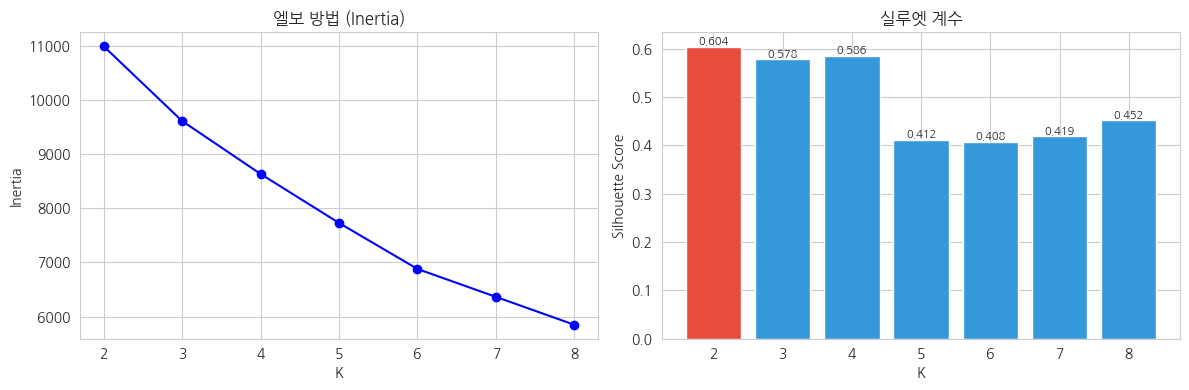

K별 실루엣 점수:
  K=2: 0.6039
  K=3: 0.5782
  K=4: 0.5859
  K=5: 0.4119
  K=6: 0.4078
  K=7: 0.4187
  K=8: 0.4523


In [2]:
FEATURES = [
    'total_books', 'review_rate', 'avg_review_length', 'archive_ratio',
    'has_unarchived', 'following_count', 'follower_count',
    'visits_made', 'visits_received_count', 'notification_read_rate',
    'hours_to_first_book', 'has_follow', 'has_review',
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])

# 엘보 + 실루엣
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = list(K_range)
axes[0].plot(ks, inertias, 'bo-')
axes[0].set_title('엘보 방법 (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].bar(ks, sil_scores, color=['#e74c3c' if s==max(sil_scores) else '#3498db' for s in sil_scores])
axes[1].set_title('실루엣 계수')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
for k, s in zip(ks, sil_scores):
    axes[1].text(k, s+0.005, f'{s:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/fig_02_elbow_silhouette.png', dpi=150)
plt.show()

print("K별 실루엣 점수:")
for k, s in zip(ks, sil_scores):
    print(f"  K={k}: {s:.4f}")


## 인사이트 — K 선택

**실루엣 점수**: K=2(0.604) > K=4(0.586) > K=3(0.578)

**K=2 기각**: 실루엣이 가장 높지만 결과를 보면 단순히 "관여도 높음 vs 낮음"으로만 나뉘어, 이미 activity_status에서 알고 있는 정보를 반복할 뿐이다.

**K=4 기각**: 4번째 군집이 5명(0.5%)짜리 아웃라이어로, 발표에서 의미 있는 페르소나로 제시하기 어렵다.

**K=3 채택**: 실루엣 0.578로 충분히 높으며, 세 군집이 각각 뚜렷하고 해석 가능한 행동 패턴을 가짐. 발표에서 "세 가지 사용자 유형"으로 명확히 스토리텔링 가능.


In [3]:
# K=3 최종 군집화
BEST_K = 3
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

PROFILE_COLS = ['total_books','review_rate','archive_ratio','following_count',
                'visits_received_count','notification_read_rate','has_review','has_follow']

profile = df.groupby('cluster')[PROFILE_COLS].mean().round(3)
profile['n'] = df.groupby('cluster').size()
profile['active_%'] = df.groupby('cluster')['activity_status'].apply(
    lambda x: (x=='active').mean()*100).round(1)
profile['long_dorm_%'] = df.groupby('cluster')['activity_status'].apply(
    lambda x: (x=='long_dormant').mean()*100).round(1)
profile['never_active_%'] = df.groupby('cluster')['activity_status'].apply(
    lambda x: (x=='never_active').mean()*100).round(1)

print(profile.to_string())


         total_books  review_rate  archive_ratio  following_count  visits_received_count  notification_read_rate  has_review  has_follow    n  active_%  long_dorm_%  never_active_%
cluster                                                                                                                                                                             
0              6.372        0.000          0.207            0.050                  4.735                   0.003       0.000       0.034  928       5.5         63.9            22.2
1             41.239        0.058          0.685            2.254                 18.597                   0.717       0.299       0.657   67      28.4         50.7             0.0
2             14.831        0.410          0.556            0.120                  9.554                   0.133       1.000       0.108   83      20.5         57.8             7.2


## 인사이트 — 군집 프로파일 및 페르소나 명명

| 군집 | 명칭 | 규모 | 특징 |
|------|------|------|------|
| 0 | **소셜 독서가** | 67명 (6%) | 책 41권, 팔로잉 있음, 알림 읽음률 72% — 앱의 소셜 기능까지 활용하는 파워유저 |
| 1 | **조용한 다수** | 922명 (86%) | 책 6권, 리뷰·팔로우 없음, 알림 무반응 — 가입 후 최소 행동만 하고 이탈 |
| 2 | **기록형 독자** | 83명 (8%) | 책 14권, 리뷰율 41%, 리뷰 작성률 100% — 소셜 없이 독서 기록 도구로만 사용 |

**해석**
- **조용한 다수(86%)가 핵심 문제**: 이들을 소셜 독서가나 기록형 독자로 전환하는 것이 앱 성장의 핵심
- **소셜 독서가 활성율 27.9% vs 조용한 다수 5.5%** → 소셜 기능(팔로우, 알림) 진입이 리텐션의 분기점
- **기록형 독자(8%)는 숨겨진 자산**: 리뷰를 쓰지만 소셜 연결이 없음 → 팔로우 1명만 연결해도 소셜 독서가로 이동 가능

**가설 연결**: H1(받은 방문 → 활성), H3(팔로잉 → 활성) — 소셜 독서가 군집이 두 가설을 동시에 지지

**발표 활용**: 세 가지 페르소나를 인물 카드 형태로 시각화, "기록형 독자 → 소셜 독서가 전환"이 핵심 전략임을 제시


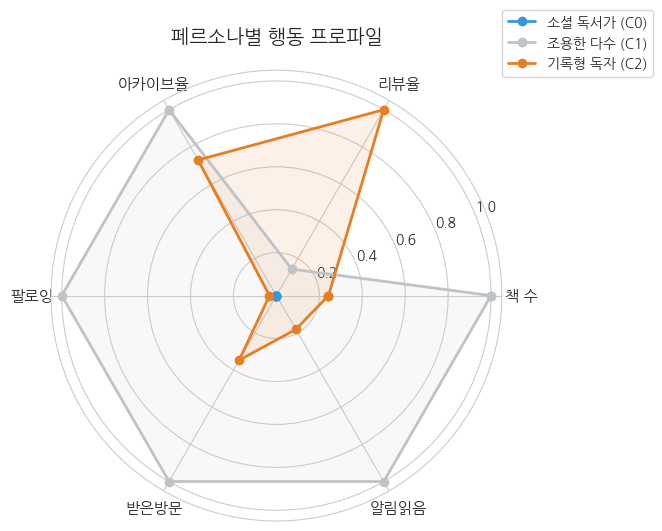

In [4]:
# 레이더 차트 — 세 페르소나 비교
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

RADAR_COLS = ['total_books','review_rate','archive_ratio',
              'following_count','visits_received_count','notification_read_rate']
RADAR_LABELS = ['책 수','리뷰율','아카이브율','팔로잉','받은방문','알림읽음']

profile_radar = df.groupby('cluster')[RADAR_COLS].mean()
# 0~1 정규화
profile_norm = (profile_radar - profile_radar.min()) / (profile_radar.max() - profile_radar.min() + 1e-9)

N = len(RADAR_COLS)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#3498db','#bdc3c7','#e67e22']
names  = ['소셜 독서가 (C0)','조용한 다수 (C1)','기록형 독자 (C2)']

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for idx, (c, name, color) in enumerate(zip([0,1,2], names, colors)):
    vals = profile_norm.loc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, size=11)
ax.set_title('페르소나별 행동 프로파일', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('../notebooks/fig_02_persona_radar.png', dpi=150)
plt.show()


## 단계 2 종합 요약

| 페르소나 | 규모 | active% | 핵심 전략 |
|----------|------|---------|-----------|
| 소셜 독서가 | 6% | 27.9% | 유지·강화 — 이들이 앱의 소셜 네트워크 허브 |
| 조용한 다수 | 86% | 5.5% | **전환 최우선** — 팔로우 1명 유도가 핵심 트리거 |
| 기록형 독자 | 8% | 20.5% | 사회적 연결 유도 — 이미 리뷰를 쓰므로 팔로우만 추가하면 됨 |

**다음 단계**: 이 군집 레이블을 피처로 활용하여, 가입 후 7일 행동만으로 휴면을 예측하는 분류 모델을 구축한다 (단계 3)
